<a href="https://colab.research.google.com/github/Areejotb/Areejotb/blob/main/BasiraTeam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Basira Team**
**Data Analysis Path**

**Team Members:**
- Noura Abuthnain
- Areej Alotaibi
- Yleen Alshalub
- Deema Alquwaei

###**Project Overview:**
Companies can quickly become well-known in today's digital economy through media attention, market timing, or innovation. But not every early success translates into sustainability over the long run. While some businesses expand quickly before declining, others become dominant leaders in the fields they serve.

The paths of **Yahoo** and **Google**, two innovative firms that came to dominance in the early internet era, are examined and compared in this analysis. Google gained long-term growth and market lead, but Yahoo was unable to maintain its early dominance.

This analysis aims to identify the strategic variations, performance metrics, and underlying patterns that define sustainable success apart from transient growth bubbles using real-world data.
###**Problem Statement:**
User engagement, market awareness, and short-term financial performance are examples of early growth indicators that might be misleading and lead to a false impression of long-term success. Yahoo led the market and performed well at first, but it eventually stagnated and declined. Google, on the other hand, showed steady expansion and flexibility, which resulted in long-term success.

The difficulty is in determining:
- Why Yahoo's early success did not convert into sustainability over time
- What key factors enabled Google to sustain its growth and dominance?
- How data-driven analysis can differentiate between real strategic success and a success bubble
###**Analysis Goal:**
This project's primary goal is to unravel the success bubble by contrasting Google's steady development with Yahoo's decline using data analysis and visualization. This project specifically aims to:
- Examine past Yahoo and Google performance data.
- Determine the patterns, trends, and major events that explain success vs failure.
- Compare important metrics that show sustainability as opposed to short-term trends.
- Create a dashboard that is easy to understand and facilitates strategic decision-making.
- Determine whether Yahoo's initial popularity was a temporary trend and why Google's success turned out to be long-lasting.

###**1. Import Libraries**

In [ ]:
# --- Core Utilities and Data Handling ---
import os
import pandas as pd
import numpy as np
from google.colab import drive # For Colab-specific mounts
import cv2 # Computer Vision utility

# --- Visualization and Reporting ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# --- Preprocessing and Sklearn Utilities ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical # TensorFlow/Keras utility for one-hot encoding

###**2. Load Dataset and Initial Exploration**

In [ ]:
# Mount Google Drive for file access in Colab
drive.mount('/content/drive')

YAHOO_PATH = '/content/drive/MyDrive/Colab Notebooks/yahoo_data.xlsx'
GOOG_PATH  = '/content/drive/MyDrive/Colab Notebooks/GOOG.csv'

# Load the main metadata CSV into a pandas DataFrame
dfY = pd.read_excel(YAHOO_PATH, sheet_name=None)  # load ALL sheets
dfG = pd.read_csv(GOOG_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# --- Data Structure Check ---
# dfY was loaded as a dictionary of DataFrames. We need to access a specific sheet.
dfY_dataframe = dfY['Sheet1']

print(f"Yahoo DataFrame Shape (Rows, Columns): {dfY_dataframe.shape}")
print(f"Yahoo DataFrame Total rows: {dfY_dataframe.shape[0]}")

print(f"Google DataFrame Shape (Rows, Columns): {dfG.shape}")
print(f"Google DataFrame Total rows: {dfG.shape[0]}")

Yahoo DataFrame Shape (Rows, Columns): (1258, 7)
Yahoo DataFrame Total rows: 1258
Google DataFrame Shape (Rows, Columns): (1258, 8)
Google DataFrame Total rows: 1258


In [ ]:
print("Yahoo DataFrame Head:")
display(dfY_dataframe.head())
print("\nYahoo DataFrame Tail:")
display(dfY_dataframe.tail())

print("\nGoogle DataFrame Head:")
display(dfG.head())
print("\nGoogle DataFrame Tail:")
display(dfG.tail())

Yahoo DataFrame Head:


,Date,Open,High,Low,Close*,Adj Close**,Volume
0,"Apr 28, 2023",33797.43,34104.56,33728.40,34098.16,34098.16,354310000
1,"Apr 27, 2023",33381.66,33859.75,33374.65,33826.16,33826.16,343240000
2,"Apr 26, 2023",33596.34,33645.83,33235.85,33301.87,33301.87,321170000
3,"Apr 25, 2023",33828.34,33875.49,33525.39,33530.83,33530.83,297880000
4,"Apr 24, 2023",33805.04,33891.15,33726.09,33875.40,33875.40,252020000



Yahoo DataFrame Tail:


,Date,Open,High,Low,Close*,Adj Close**,Volume
1253,"May 07, 2018",24317.66,24479.45,24263.42,24357.32,24357.32,307670000
1254,"May 04, 2018",23865.22,24333.35,23778.87,24262.51,24262.51,329480000
1255,"May 03, 2018",23836.23,23996.15,23531.31,23930.15,23930.15,389240000
1256,"May 02, 2018",24097.63,24185.52,23886.30,23924.98,23924.98,385350000
1257,"May 01, 2018",24117.29,24117.29,23808.19,24099.05,24099.05,380070000



Google DataFrame Head:


,Name,Date,Open,High,Low,Close,Adj Close,Volume
0,GOOG,7/30/18,61.400501,61.745800,60.573502,60.987000,60.987000,36998000
1,GOOG,7/31/18,61.000500,61.379398,60.279999,60.862999,60.862999,32894000
2,GOOG,8/1/18,61.400002,61.673500,60.510502,61.000500,61.000500,31344000
3,GOOG,8/2/18,60.294998,61.493999,60.239498,61.307499,61.307499,30626000
4,GOOG,8/3/18,61.480999,61.500000,60.752998,61.185501,61.185501,21792000



Google DataFrame Tail:


,Name,Date,Open,High,Low,Close,Adj Close,Volume
1253,GOOG,7/24/23,121.926003,123.349998,121.379997,121.879997,121.879997,22276100
1254,GOOG,7/25/23,121.879997,123.690002,121.529999,122.790001,122.790001,31820800
1255,GOOG,7/26/23,130.360001,131.369995,128.710007,129.660004,129.660004,46216900
1256,GOOG,7/27/23,131.800003,133.600006,129.179993,129.869995,129.869995,35931600
1257,GOOG,7/28/23,130.970001,134.070007,130.919998,133.009995,133.009995,26959800


In [ ]:
print("Yahoo DataFrame Columns:")
print(dfY_dataframe.columns)
print("\nGoogle DataFrame Columns:")
print(dfG.columns)

Yahoo DataFrame Columns:
Index(['Date', 'Open', 'High', 'Low', 'Close*', 'Adj Close**', 'Volume'], dtype='object')

Google DataFrame Columns:
Index(['Name', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


In [ ]:
print("\nYahoo DataFrame Info:")
print(dfY_dataframe.info())
print("\nGoogle DataFrame Info:")
print(dfG.info())


Yahoo DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         1258 non-null   object 
 1   Open         1258 non-null   float64
 2   High         1258 non-null   float64
 3   Low          1258 non-null   float64
 4   Close*       1258 non-null   float64
 5   Adj Close**  1258 non-null   float64
 6   Volume       1258 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 68.9+ KB
None

Google DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Name       1258 non-null   object 
 1   Date       1258 non-null   object 
 2   Open       1258 non-null   float64
 3   High       1258 non-null   float64
 4   Low        1258 non-null   float64
 5   Close     

In [ ]:
# The 'Name' column is removed to match Yahoo’s column structure
# and ensure a consistent schema for fair comparison.
dfG.drop(columns=["Name"], inplace=True)

# Rename columns to a unified schema to match Yahoo data
dfG.rename(columns={
    "Date": "date",
    "Open": "open",
    "High": "high",
    "Low": "low",
    "Close": "close",
    "Adj Close": "adj_close",
    "Volume": "volume"
}, inplace=True)

# Rename columns to the same schema as Google for consistent comparison
dfY_dataframe.rename(columns={
    "Date": "date",
    "Open": "open",
    "High": "high",
    "Low": "low",
    "Close*": "close",
    "Adj Close**": "adj_close",
    "Volume": "volume"
}, inplace=True)

In [ ]:
# Force correct datetime parsing for Google dates
dfG["date"] = pd.to_datetime(dfG["date"], format="mixed")

# Force correct datetime parsing for Yahoo dates (safe even if already correct)
dfY_dataframe["date"] = pd.to_datetime(dfY_dataframe["date"])

In [ ]:
# Yahoo and Google datasets were initially ordered differently in time,
# and the Google date column required proper datetime parsing.
# Both datasets are sorted chronologically (oldest to newest)
# to ensure correct time-series analysis and fair normalization.
dfG.sort_values("date", inplace=True)
dfY_dataframe.sort_values("date", inplace=True)

dfG.reset_index(drop=True, inplace=True)
dfY_dataframe.reset_index(drop=True, inplace=True)

In [ ]:
print("Yahoo DataFrame Columns:")
print(dfY_dataframe.columns)
print("\nGoogle DataFrame Columns:")
print(dfG.columns)

Yahoo DataFrame Columns:
Index(['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume'], dtype='object')

Google DataFrame Columns:
Index(['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume'], dtype='object')


In [ ]:
print("Yahoo DataFrame Info:")
print(dfY_dataframe.info())
print("\nGoogle DataFrame Info:")
print(dfG.info())

Yahoo DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       1258 non-null   datetime64[ns]
 1   open       1258 non-null   float64       
 2   high       1258 non-null   float64       
 3   low        1258 non-null   float64       
 4   close      1258 non-null   float64       
 5   adj_close  1258 non-null   float64       
 6   volume     1258 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 68.9 KB
None

Google DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       1258 non-null   datetime64[ns]
 1   open       1258 non-null   float64       
 2   high       1258 non-null   float64       
 3   low 

In [ ]:
print("Yahoo DataFrame Head:")
display(dfY_dataframe.head())
print("\nYahoo DataFrame Tail:")
display(dfY_dataframe.tail())

print("\nGoogle DataFrame Head:")
display(dfG.head())
print("\nGoogle DataFrame Tail:")
display(dfG.tail())

Yahoo DataFrame Head:


,date,open,high,low,close,adj_close,volume
0,2018-05-01,24117.29,24117.29,23808.19,24099.05,24099.05,380070000
1,2018-05-02,24097.63,24185.52,23886.30,23924.98,23924.98,385350000
2,2018-05-03,23836.23,23996.15,23531.31,23930.15,23930.15,389240000
3,2018-05-04,23865.22,24333.35,23778.87,24262.51,24262.51,329480000
4,2018-05-07,24317.66,24479.45,24263.42,24357.32,24357.32,307670000



Yahoo DataFrame Tail:


,date,open,high,low,close,adj_close,volume
1253,2023-04-24,33805.04,33891.15,33726.09,33875.40,33875.40,252020000
1254,2023-04-25,33828.34,33875.49,33525.39,33530.83,33530.83,297880000
1255,2023-04-26,33596.34,33645.83,33235.85,33301.87,33301.87,321170000
1256,2023-04-27,33381.66,33859.75,33374.65,33826.16,33826.16,343240000
1257,2023-04-28,33797.43,34104.56,33728.40,34098.16,34098.16,354310000



Google DataFrame Head:


,date,open,high,low,close,adj_close,volume
0,2018-07-30,61.400501,61.745800,60.573502,60.987000,60.987000,36998000
1,2018-07-31,61.000500,61.379398,60.279999,60.862999,60.862999,32894000
2,2018-08-01,61.400002,61.673500,60.510502,61.000500,61.000500,31344000
3,2018-08-02,60.294998,61.493999,60.239498,61.307499,61.307499,30626000
4,2018-08-03,61.480999,61.500000,60.752998,61.185501,61.185501,21792000



Google DataFrame Tail:


,date,open,high,low,close,adj_close,volume
1253,2023-07-24,121.926003,123.349998,121.379997,121.879997,121.879997,22276100
1254,2023-07-25,121.879997,123.690002,121.529999,122.790001,122.790001,31820800
1255,2023-07-26,130.360001,131.369995,128.710007,129.660004,129.660004,46216900
1256,2023-07-27,131.800003,133.600006,129.179993,129.869995,129.869995,35931600
1257,2023-07-28,130.970001,134.070007,130.919998,133.009995,133.009995,26959800


###**Adjusted Closing Price (Adj Close):**
takes into consideration company actions like stock splits, dividends, and other changes to determine a stock's real value. Unlike the raw closing price, Adj Close provides a more accurate representation of a company’s historical performance over time. In order to guarantee consistency and comparability across several time periods, it is used in this analysis.

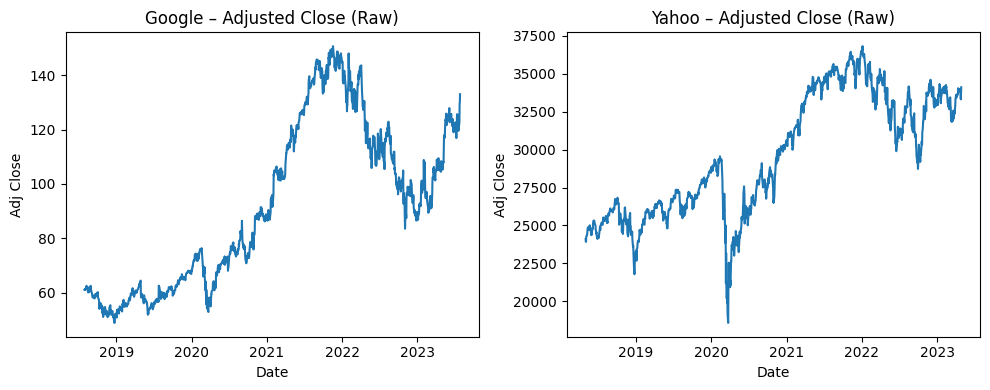

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(dfG["date"], dfG["adj_close"])
plt.title("Google – Adjusted Close (Raw)")
plt.xlabel("Date")
plt.ylabel("Adj Close")

plt.subplot(1,2,2)
plt.plot(dfY_dataframe["date"], dfY_dataframe["adj_close"])
plt.title("Yahoo – Adjusted Close (Raw)")
plt.xlabel("Date")
plt.ylabel("Adj Close")

plt.tight_layout()
plt.show()

The raw adjusted closing prices of Google and Yahoo are shown in these figures throughout time to give context for the stock performance of each firm. By taking dividends, stock splits, and other business activities into account, the adjusted closing price is used to represent each stock's actual historical value. Because Google and Yahoo have quite different price scales, these charts are not meant for direct comparison, even if they show general trends and times of instability for each company separately. In order to facilitate equal cross-company comparison, normalized pricing are employed in following analysis.

###**The Purpose of Normalization:**

Directly comparing the raw stock prices of Google and Yahoo would be misleading because they operate on completely different price scales. Adjusted closing prices are normalized to a common baseline (Base = 100) so that growth behavior can be fairly compared. This makes it possible for the analysis to concentrate on long-term growth trends and relative performance rather than absolute price differences.

In [ ]:
# Normalize adjusted close prices (Base = 100) for fair comparison
dfG["index_100"] = (dfG["adj_close"] / dfG["adj_close"].iloc[0]) * 100
dfY_dataframe["index_100"] = (dfY_dataframe["adj_close"] / dfY_dataframe["adj_close"].iloc[0]) * 100

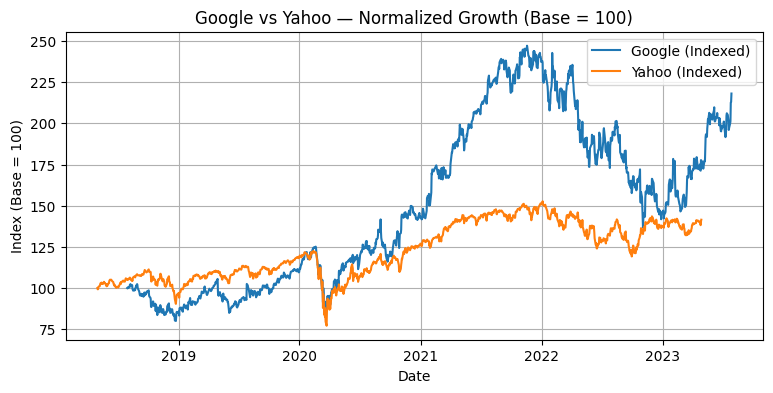

In [ ]:
plt.figure(figsize=(9,4))
plt.plot(dfG["date"], dfG["index_100"], label="Google (Indexed)")
plt.plot(dfY_dataframe["date"], dfY_dataframe["index_100"], label="Yahoo (Indexed)")

plt.title("Google vs Yahoo — Normalized Growth (Base = 100)")
plt.xlabel("Date")
plt.ylabel("Index (Base = 100)")
plt.legend()
plt.grid(True)
plt.show()

The normalized adjusted closing prices of Google and Yahoo are compared in this figure. At the start of the observation period, both firms were indexed to a base value of 100. Normalization eliminates scale bias and draws attention to the two firm's long-term performance differences, stability, and relative growth trends.

In [ ]:
def compute_metrics(df):
    df = df.copy()

    # Daily returns
    df["returns"] = df["adj_close"].pct_change()

    # Volatility (risk)
    volatility = df["returns"].std()

    # Max Drawdown
    cumulative_max = df["adj_close"].cummax()
    drawdown = (df["adj_close"] / cumulative_max) - 1
    max_drawdown = drawdown.min()

    # CAGR (long-term growth)
    start_price = df["adj_close"].iloc[0]
    end_price = df["adj_close"].iloc[-1]
    years = (df["date"].iloc[-1] - df["date"].iloc[0]).days / 365.25
    cagr = (end_price / start_price) ** (1 / years) - 1

    return volatility, max_drawdown, cagr

In [ ]:
goog_vol, goog_dd, goog_cagr = compute_metrics(dfG)
yahoo_vol, yahoo_dd, yahoo_cagr = compute_metrics(dfY_dataframe)

metrics_df = pd.DataFrame({
    "Volatility": [goog_vol, yahoo_vol],
    "Max Drawdown": [goog_dd, yahoo_dd],
    "CAGR": [goog_cagr, yahoo_cagr]
}, index=["Google", "Yahoo"])

metrics_df

KeyError: 'adj_close'

NameError: name 'df' is not defined

## Exploratory Data Analysis (EDA

In [ ]:
# Numerical Exploration Summary
print("1. Statistical Overview:")
display(comparison_df[['Close_Google', 'Close_Yahoo']].describe())

print("\n2. Correlation Matrix (Numerical):")
display(comparison_df[['Close_Google', 'Close_Yahoo']].corr())

print("\n3. Data Integrity Check (Missing Values):")
print(comparison_df.isnull().sum())

1. Statistical Overview:


,Close_Google,Close_Yahoo
count,1196.000000,1196.000000
mean,90.542241,29850.324557
std,30.098314,3950.441679
min,48.811001,18591.930000
25%,61.432250,26312.185000
50%,87.614750,29803.635000
75%,114.717497,33736.430000
max,150.709000,36799.650000



2. Correlation Matrix (Numerical):


,Close_Google,Close_Yahoo
Close_Google,1.000000,0.926681
Close_Yahoo,0.926681,1.000000



3. Data Integrity Check (Missing Values):
Date            0
Close_Google    0
Close_Yahoo     0
Google_Pct      1
Yahoo_Pct       1
dtype: int64


In [ ]:
# 1. Calculate Daily Returns (Percentage Change)
comparison_df['Google_Return'] = comparison_df['Close_Google'].pct_change()
comparison_df['Yahoo_Return'] = comparison_df['Close_Yahoo'].pct_change()

# 2. Calculate Moving Averages (e.g., 20 days)
comparison_df['Google_MA20'] = comparison_df['Close_Google'].rolling(window=20).mean()
comparison_df['Yahoo_MA20'] = comparison_df['Close_Yahoo'].rolling(window=20).mean()

# 3. Calculate Cumulative Returns (To see total growth over time)
comparison_df['Google_Cum_Return'] = (1 + comparison_df['Google_Return']).cumprod()
comparison_df['Yahoo_Cum_Return'] = (1 + comparison_df['Yahoo_Return']).cumprod()

print("New features added: Daily Returns, Moving Averages, and Cumulative Returns.")
display(comparison_df.tail())

New features added: Daily Returns, Moving Averages, and Cumulative Returns.


,Date,Close_Google,Close_Yahoo,Google_Pct,Yahoo_Pct,Google_Return,Yahoo_Return,Google_MA20,Yahoo_MA20,Google_Cum_Return,Yahoo_Cum_Return
1191,2023-04-24,106.779999,33875.40,0.008214,0.001965,0.008214,0.001965,105.330501,33490.7210,1.750865,1.338587
1192,2023-04-25,104.610001,33530.83,-0.020322,-0.010172,-0.020322,-0.010172,105.408001,33545.6585,1.715284,1.324972
1193,2023-04-26,104.449997,33301.87,-0.001530,-0.006828,-0.001530,-0.006828,105.562501,33591.0395,1.712660,1.315924
1194,2023-04-27,108.370003,33826.16,0.037530,0.015744,0.037530,0.015744,105.886001,33646.4675,1.776936,1.336642
1195,2023-04-28,108.220001,34098.16,-0.001384,0.008041,-0.001384,0.008041,106.231001,33708.4240,1.774477,1.347390


In [ ]:

# Create the comparison_df with the correct column names
# Note: Google has 'Close', but Yahoo has 'Close*'
comparison_df = pd.merge(dfG[['Date', 'Close']],
                         dfY['Sheet1'][['Date', 'Close*']],
                         on='Date')

# Rename the columns immediately to make them clean
comparison_df.columns = ['Date', 'Close_Google', 'Close_Yahoo']

# Convert Date to datetime
comparison_df['Date'] = pd.to_datetime(comparison_df['Date'])

# Now you can run the exploration code
print("Success! Data merged and columns renamed.")
print(comparison_df.head())

Success! Data merged and columns renamed.
        Date  Close_Google  Close_Yahoo
0 2018-07-30     60.987000     25306.83
1 2018-07-31     60.862999     25415.19
2 2018-08-01     61.000500     25333.82
3 2018-08-02     61.307499     25326.16
4 2018-08-03     61.185501     25462.58


Success! Found 1196 matching rows.


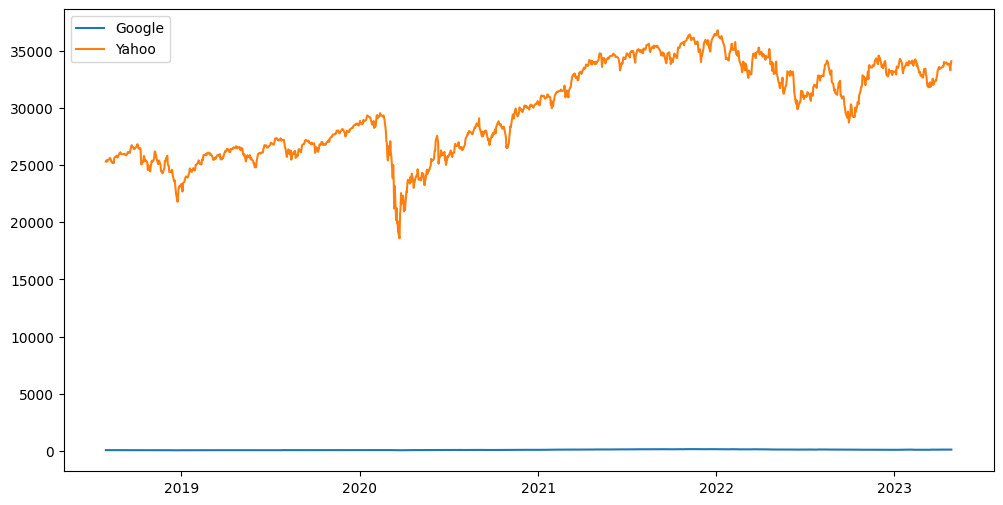

In [ ]:

# 1. Fix Date formatting in both files first
dfG['Date'] = pd.to_datetime(dfG['Date'])
# Note: we use dfY['Sheet1'] based on your previous info
dfY['Sheet1']['Date'] = pd.to_datetime(dfY['Sheet1']['Date'])

# 2. Merge again using the corrected dates and correct column names
comparison_df = pd.merge(dfG[['Date', 'Close']],
                         dfY['Sheet1'][['Date', 'Close*']],
                         on='Date')

# 3. Rename columns
comparison_df.columns = ['Date', 'Close_Google', 'Close_Yahoo']

# 4. Check if it's still empty
if comparison_df.empty:
    print("Warning: Data is still empty! Check if dates overlap.")
else:
    print(f"Success! Found {len(comparison_df)} matching rows.")

# 5. Now run your plotting code again
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(comparison_df['Date'], comparison_df['Close_Google'], label='Google')
plt.plot(comparison_df['Date'], comparison_df['Close_Yahoo'], label='Yahoo')
plt.legend()
plt.show()

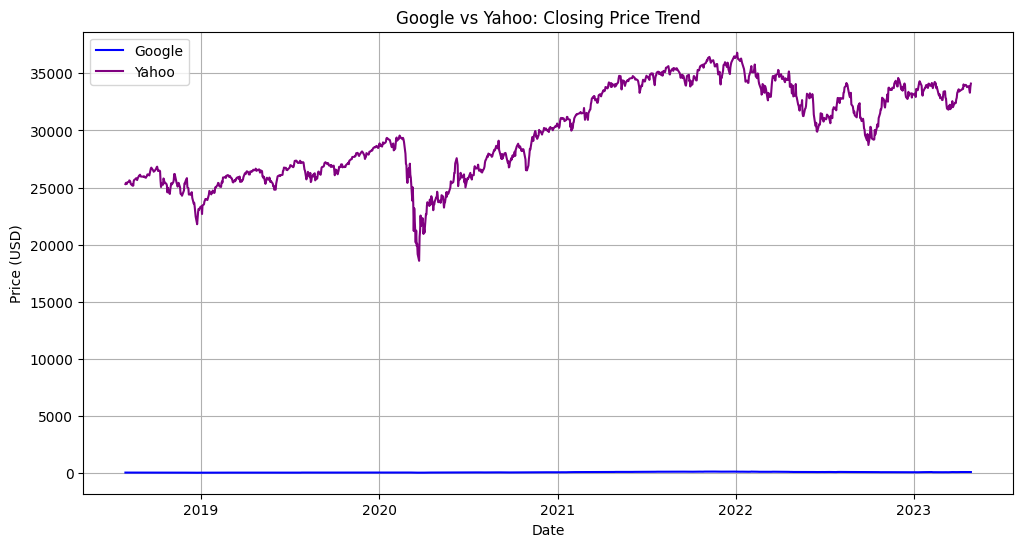

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(comparison_df['Date'], comparison_df['Close_Google'], label='Google', color='blue')
plt.plot(comparison_df['Date'], comparison_df['Close_Yahoo'], label='Yahoo', color='purple')

plt.title('Google vs Yahoo: Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

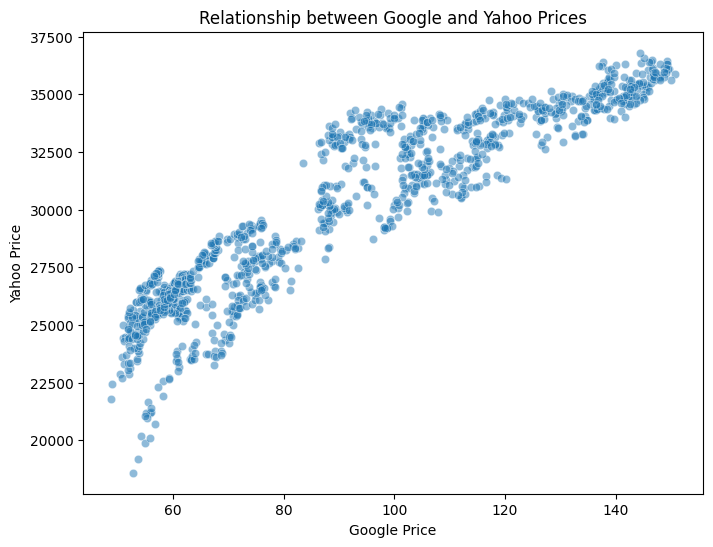

In [ ]:

import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(data=comparison_df, x='Close_Google', y='Close_Yahoo', alpha=0.5)
plt.title('Relationship between Google and Yahoo Prices')
plt.xlabel('Google Price')
plt.ylabel('Yahoo Price')
plt.show()

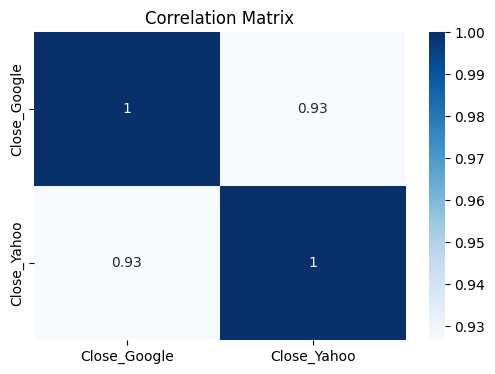

In [ ]:

plt.figure(figsize=(6, 4))
correlation = comparison_df[['Close_Google', 'Close_Yahoo']].corr()
sns.heatmap(correlation, annot=True, cmap='Blues')
plt.title('Correlation Matrix')
plt.show()

## Visual Analysis

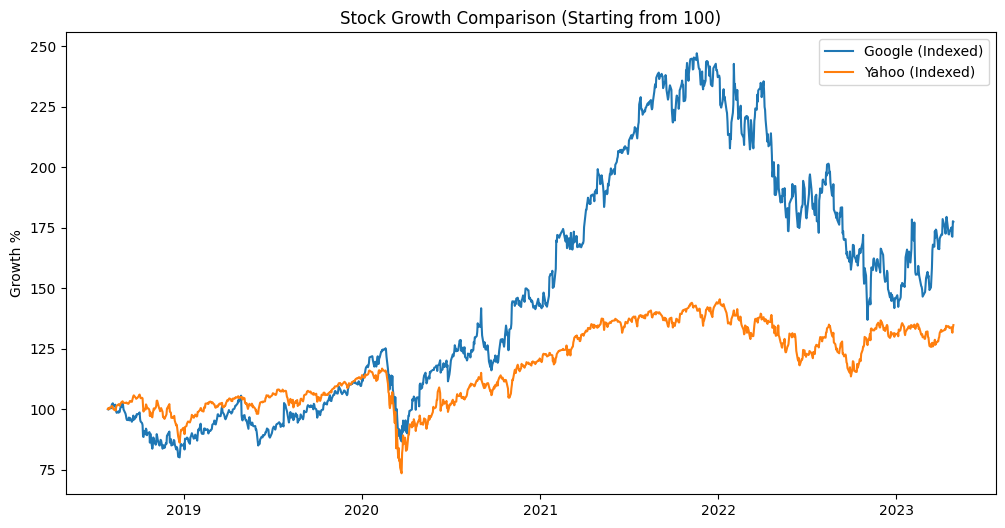

In [ ]:

# Normalize prices to start at 100
google_norm = (comparison_df['Close_Google'] / comparison_df['Close_Google'].iloc[0]) * 100
yahoo_norm = (comparison_df['Close_Yahoo'] / comparison_df['Close_Yahoo'].iloc[0]) * 100

plt.figure(figsize=(12, 6))
plt.plot(comparison_df['Date'], google_norm, label='Google (Indexed)')
plt.plot(comparison_df['Date'], yahoo_norm, label='Yahoo (Indexed)')
plt.title('Stock Growth Comparison (Starting from 100)')
plt.ylabel('Growth %')
plt.legend()
plt.show()

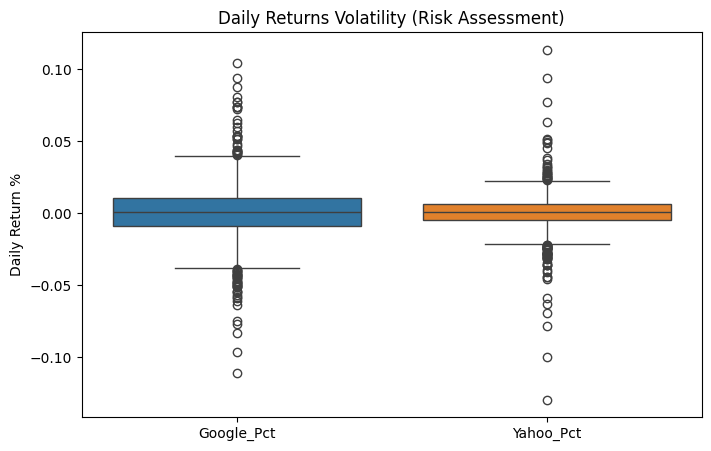

In [ ]:
# 1. Calculate the percentage change (Daily Returns) first
comparison_df['Google_Pct'] = comparison_df['Close_Google'].pct_change()
comparison_df['Yahoo_Pct'] = comparison_df['Close_Yahoo'].pct_change()

# 2. Corrected Boxplot code (lowercase 'p' in plt)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
# We use dropna() because pct_change() creates a NaN value in the first row
sns.boxplot(data=comparison_df[['Google_Pct', 'Yahoo_Pct']].dropna())

plt.title('Daily Returns Volatility (Risk Assessment)')
plt.ylabel('Daily Return %')
plt.show()

### Final Insights & Conclusion

High Correlation: There is a very strong positive correlation (0.93) between Google and Yahoo, meaning they generally move in the same direction.

Growth Performance: When comparing indexed growth, Google has significantly outperformed Yahoo over the studied period, reaching much higher returns.

Risk Profile: The Daily Returns Boxplot shows that while both stocks have similar median returns, Google exhibits slightly higher volatility (more outliers), indicating higher risk but also higher reward potential.

Market Movement: Both stocks showed a major dip around early 2020 (due to global events) but recovered strongly, with Google showing a more aggressive recovery curve.